# Ocean volume, salt and freshwater conservation — Full-CPL spin-up + piControl

Figures:
* `Full-CPL_PE_vs_dSSH_salt_closure_1x3_annual_0-2500.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

**Note:** The budget figure also reads `data/atm_flux/` written by `12_atm_flux_ctrl_analysis`.

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os, re, glob, warnings, string
import numpy as np
import xarray as xr
import cftime
import contextlib

from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, FixedLocator
import pandas as pd 

from util.ctrl_plotting import CoupledBudgetPlotter
from util.ctrl_processing import OceanBudgetBuilder
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ocn_conserve"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ocn_conserve"          # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPERIMENT     = "Full-CPL"    # experiment analysed (spin-up followed by its piControl)
CTRL_YEARS     = (0, 2500)     # combined spin-up + piControl model years (axes, cache/figure names)


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_conserve
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_conserve


## 1 Ocean volume, salt and freshwater terms
### Settings

In [4]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series"
file_stem        = "mpasTimeSeriesOcean"
file_suffix      = ".nc"
stamp_regex      = None
xr_engine        = "netcdf4"
suffix           = "annual"
spinup_period    = CTRL_YEARS   # naming only
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = True   # "rebuild everything" switch

# layer-region raw names
vol_global_name = "timeMonthly_avg_volumeCellGlobal"
sum_mask_name   = "timeMonthly_avg_avgValueWithinOceanLayerRegion_sumLayerMaskValue"
area_name       = "timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerArea"
thick_name      = "timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerThickness"
sal_name        = "timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerSalinity"
region_dim = "nOceanRegionsTmp"
z_dim      = "nVertLevels"

choose_region = "global"
z_sel = None

# === diagnostics variable names (final combined annual will contain these) ===
dh_mm_var        = "ocean_volume_change_equiv_mm"
dh_rate_mmyr_var = "ocean_volume_tendency_equiv_mm_per_yr"
salt_mass_var        = "ocean_salt_mass_kg"
salt_mass_d_var      = "ocean_salt_mass_change_kg"
salt_mass_dfrac_var  = "ocean_salt_mass_change_frac"

vol_var        = "ocean_volume"
vol_rec_var    = "ocean_volume_reconstructed"
dV_var         = "ocean_volume_change_m3"
dV_frac_var    = "ocean_volume_change_frac"

sbar_var       = "mean_salinity_from_integral"
salt_int_var   = "salt_content_integral_psu_m3"
salt_sbar_var  = "salt_content_from_sbar_psu_m3"
salt_resid_var = "salt_content_residual_frac"
salt_proxy_var = "salt_content_proxy_kgkg_m3"

# freshwater-equivalent vars produced by build_combined_layerregion_annual()
fw_mm_var        = "ocean_salt_freshwater_equiv_mm"
fw_rate_mmyr_var = "ocean_salt_freshwater_equiv_mm_per_yr"

vars_to_build = (
    vol_var, vol_rec_var, dV_var, dV_frac_var,
    dh_mm_var, dh_rate_mmyr_var,
    sbar_var, salt_int_var, salt_sbar_var, salt_resid_var, salt_proxy_var,
    salt_mass_var, salt_mass_d_var, salt_mass_dfrac_var,
    fw_mm_var, fw_rate_mmyr_var,
)

# optional area/density knobs
area_cell_name = "areaCell"
ocean_area_m2  = None
rho0           = 1026.0

mpas_cfg = dict(
    vol_global_name=vol_global_name,
    sum_mask_name=sum_mask_name,
    area_name=area_name,
    thick_name=thick_name,
    sal_name=sal_name,
    region_dim=region_dim,
    z_dim=z_dim,
    choose_region=choose_region,
    z_sel=z_sel,
)

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] choose_region={choose_region}, z_sel={z_sel}")
print(f"[INFO] ocean_area_m2={'auto(sum(areaCell))' if ocean_area_m2 is None else ocean_area_m2}, rho0={rho0}")
print(f"[INFO] force_reprocess={force_reprocess} (propagated to combined + tidy)")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] choose_region=global, z_sel=None
[INFO] ocean_area_m2=auto(sum(areaCell)), rho0=1026.0
[INFO] force_reprocess=True (propagated to combined + tidy)


### Compute & plot

In [5]:
# === 1) Build per-case annual primitives (cached) ===
builder = OceanBudgetBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,
    file_suffix=file_suffix,
    stamp_regex=stamp_regex,
    xr_engine=xr_engine,
    var_name=sal_name,              # not used by this mode; kept for compatibility
    force_reprocess=force_reprocess,
)

region_tag = str(choose_region).replace(".", "p")
z_tag = "allz" if z_sel is None else f"z{z_sel}"
annual_label = f"ocn_layerregion_prims_{experiment}_{region_tag}_{z_tag}"

paths = builder.build_sources(
    out_dir=out_dir,
    var_name=annual_label,
    suffix=suffix,
    mode="ocean_vol_sbar_layerregion",
    **mpas_cfg,
)

print(f"[OK] Spin-up annual primitives:   {paths['spinup']}")
print(f"[OK] piControl annual primitives: {paths['piControl']}")

# === 2) Build ONE combined annual diagnostics file (ΔV, salt mass drift, FW-equiv, etc.) ===
combined_annual = os.path.join(
    out_dir,
    f"ocn_conserve_{experiment}_{region_tag}_{z_tag}_combined_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)

combined_annual = builder.build_combined_layerregion_annual(
    spinup_nc=paths["spinup"],
    pctl_nc=paths["piControl"],
    combined_annual_nc=combined_annual,
    sequence=sequence,
    force=force_reprocess,  # <-- IMPORTANT: propagate rebuild intent
    ocean_area_m2=ocean_area_m2,
    area_cell_name=area_cell_name,
    rho0=rho0,
    # optionally:
    # S0_kgkg=34.7e-3,
    # use_S0_from_first_year=True,
)

print(f"[OK] Combined annual diagnostics: {combined_annual}")

# === 3) Build tidy (filter/trend) files from the combined annual diagnostics ===
tidy_paths = {}
for v in vars_to_build:
    tidy_nc = os.path.join(
        out_dir,
        f"{v}_{experiment}_combined_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
    )
    tidy_paths[v] = builder.build_tidy_from_combined_annual(
        annual_nc=combined_annual,
        out_nc=tidy_nc,
        var_name=v,
        filter_window=filter_window,
        trend_windows=trend_windows,
        add_per_decade=add_per_decade,
        force=force_reprocess,        # <-- IMPORTANT: propagate rebuild intent
        preserve_year_axis=True,      # <-- keep consistent year axis across variables
    )

print("[OK] Wrote tidies from combined annual diagnostics:")
for k, v in tidy_paths.items():
    print(f"   - {k}: {v}")

# === 4) Quick sanity summary ===
for v in vars_to_build:
    try:
        builder.summarize_tidy(
            tidy_paths[v],
            var_name=v,
            filter_window=filter_window,
            trend_windows=trend_windows
        )
    except Exception as e:
        print(f"[WARN] summarize_tidy failed for {v}: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[OK] Spin-up annual primitives:   /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/fw_salt_budget/20231209.v3.LR.piControl-spinup.chrysalis_ocn_layerregion_prims_Full-CPL_global_allz_timeseries_annual.nc
[OK] piControl annual primitives: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/fw_salt_budget/v3.LR.piControl_ocn_layerregion_prims_Full-CPL_global_allz_timeseries_annual.nc
[OK] Combined annual diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/fw_salt_budget/ocn_conserve_Full-CPL_global_allz_combined_annual_0-2500.nc
[OK] Wrote tidies from combined annual diagnostics:
   - ocean_volume: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/fw_salt_budget/ocean_volume_Full-CPL_combined_annual_0-2500.nc
   - ocean_volume_reconstructed: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/fw_salt_budget/ocean_volume_reconst

## 2 Budget closure figure
### Settings

In [6]:
data_dir    = f"{OUTPUT_ROOT}/data"
fig_dir     = FIG_DIR
os.makedirs(fig_dir, exist_ok=True)

experiment    = EXPERIMENT
suffix        = "annual"
plot_syear    = CTRL_YEARS[0]
plot_eyear    = CTRL_YEARS[1]
trend_fit     = (1, 2500)   # use your preferred fit window
filter_window = 11


### Compute & plot

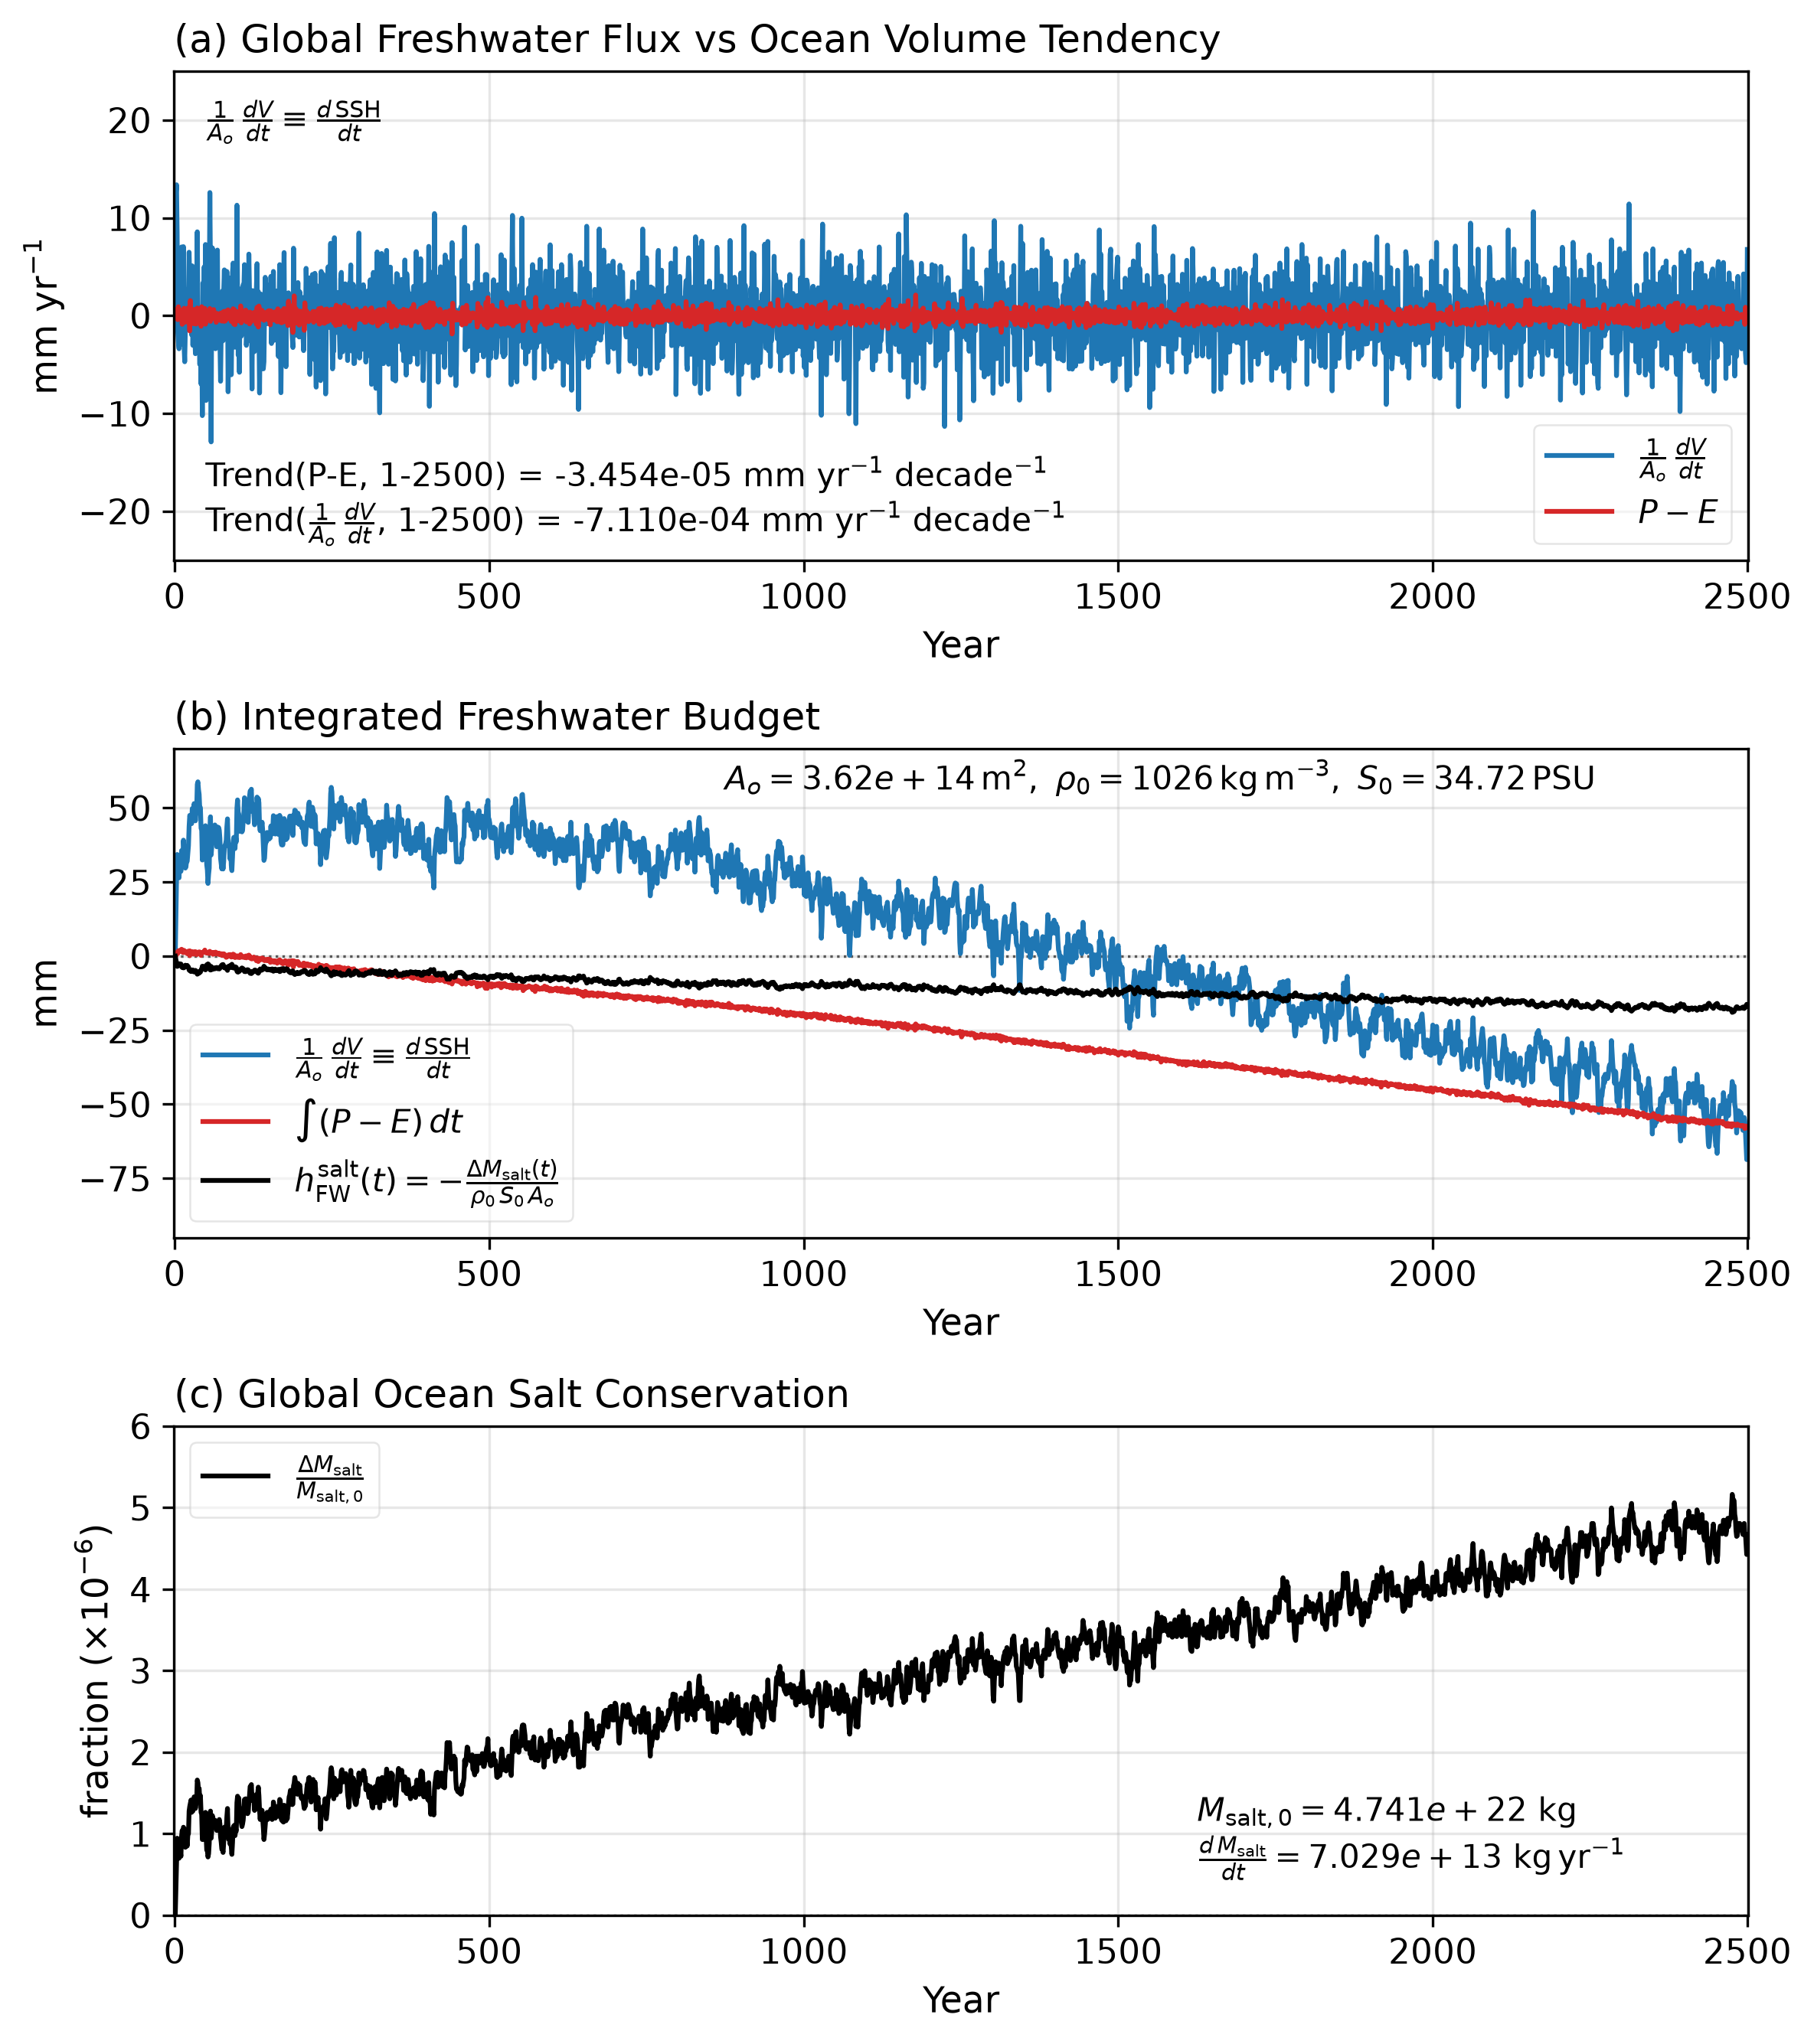

[PLOT] Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_conserve/Full-CPL_PE_vs_dSSH_salt_closure_1x3_annual_0-2500.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_conserve


In [7]:
plotter = CoupledBudgetPlotter(xr_engine="netcdf4")

# --- inputs ---
atm_tidy = plotter._require(
    os.path.join(data_dir,"atm_flux",f"{experiment}_energy_timeseries_{suffix}.nc"),
    "atm_tidy"
)

ocn_conserve = plotter._require(
    os.path.join(data_dir,"ocn_conserve",f"ocn_conserve_{experiment}_global_allz_combined_{suffix}_0-2500.nc"),
    "ocn_conserve (combined ocean diagnostics)"
)

# --- output ---
out_pdf = os.path.join(
    fig_dir,
    f"{experiment}_PE_vs_dSSH_salt_closure_1x3_{suffix}_{plot_syear}-{plot_eyear}.pdf"
)

out_path = plotter.plot_global_fw_and_salt_budget(
    atm_tidy_nc=atm_tidy,
    ocn_conserve_nc=ocn_conserve,
    out_path=out_pdf,
    flux_var="MASSFLUX",     # file stores E-P for this variable
    flux_units="mm/yr",
    flux_form="P-E",         # what you want on the plot
    flux_data_form="E-P",    # what the file actually contains
    filter_window=filter_window,
    trend_fit_range=trend_fit,
    syear=plot_syear,
    eyear=plot_eyear,
    title=None,  # f"{experiment}: global freshwater & salt budget closure",
    # --- Y-axis controls ---
    flux_ylim=(-25.0, 25.0),        # panel (a)
    fluxint_ylim=(-95, 70),         # panel (b)
    saltfrac_ylim=(0, 6),          # panel (c) (×1e-6)
    do_show=True,
    figsize=(8, 9),                # recommended for 1x3
    layout="3x1",
    dpi=300,
)

print("[PLOT] Saved:", out_path)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
